In [1]:
# tensorcircuit[cloud] version = 0.12.0 auto with numpy, need uninstall and "numpy<2.0", or complex warning
# pip install qiskit is the latest version 2.1.2 , conda install "qiskit<1" = 0.4.6
import qiskit.version
print("Qiskit version:", qiskit.version.get_version_info())

# Set "tencent_base_url" first, must be run inside Tencent WiFi
from tensorcircuit.cloud import apis
apis.set_token("lDgLDPni4XvEi0TvBCTEDzohVjRSHhH64LCR2rogLBTDwpR24QSQ1qYsMNsmtvi8xyj7Ie56A3zoxP0kpPmSWzxZT9iE5J8OQB75BPmynbnxGEaROdPeANMfxk4sFWKv.kGRTXjCvup-srLpxqzGzVHS")
apis.list_devices(state = "on")

Qiskit version: 0.46.3


Please first ``pip install -U cirq`` to enable related functionality in translation module


[tencent::simulator:tc,
 tencent::tianji_m2v16s1,
 tencent::tianji_s2,
 tencent::tianji_m2v14s4,
 tencent::tianji_m2v15s3,
 tencent::tianji_m2v14s2,
 tencent::tianji_s2v7,
 tencent::tianji_s2v6,
 tencent::tianji_m2]

/opt/miniconda3/envs/TensorCircuit/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:266: FutureWarning: The default matplotlib drawer scheme will be changed to "iqp" in a following release. To silence this warning, specify the current default explicitly as style="clifford", or the new default as style="iqp".
  self._style, def_font_ratio = load_style(self._style)


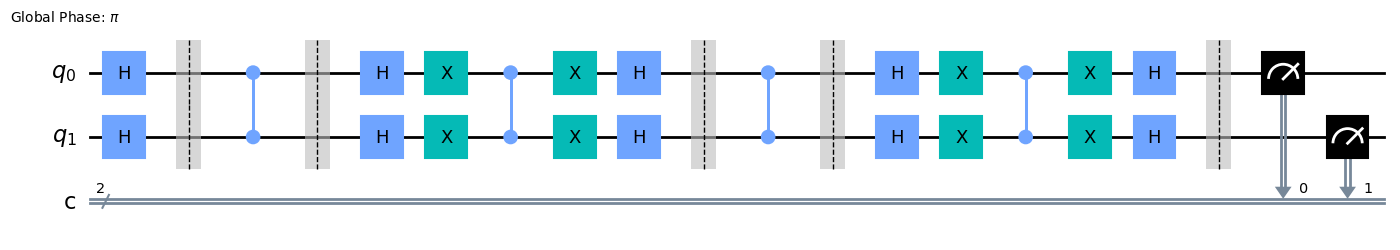

In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np

# 创建量子寄存器和经典寄存器
qr = QuantumRegister(2, 'q')
cr = ClassicalRegister(2, 'c')
qc = QuantumCircuit(qr, cr)

# 初始化：对所有量子比特应用 Hadamard 门
qc.h(qr)
qc.barrier()


for i in range(2):  # Grover 算法迭代次数, 2 好像就转过了
    # Oracle: 标记目标状态 |11⟩
    qc.cz(0, 1)  # 对状态|11⟩加负号
    qc.barrier()

    # Diffusion operator（反射算子）H(2|00⟩⟨00|-I)H
    qc.h(qr)
    
    qc.x(qr) # 只有 |00⟩ 进来会变成 |11⟩ 然后添加反号
    qc.cz(0, 1)
    qc.global_phase = np.pi  # 添加全局相位来修正负号，只有 |00⟩ 会分量不反号
    qc.x(qr)
    
    qc.h(qr)
    qc.barrier()

# 测量
qc.measure(qr, cr)

# 画出电路图
qc.draw('mpl')

In [19]:
import tensorcircuit as tc
# 'qiskit.circuit.Qubit' object has no attribute 'index'
c_from_qiskit = tc.Circuit.from_qiskit(qc) # need qiskit <= 1.0, can fit with barrier
c_from_qiskit.draw(idle_wires=False)

┌───┐   ┌───┐┌───┐   ┌───┐┌───┐┌─┐   
q_0: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├┤M├───
     ├───┤ │ ├───┤├───┤ │ ├───┤├───┤└╥┘┌─┐
q_1: ┤ H ├─■─┤ H ├┤ X ├─■─┤ X ├┤ H ├─╫─┤M├
     └───┘   └───┘└───┘   └───┘└───┘ ║ └╥┘
c: 2/════════════════════════════════╩══╩═
                                     0  1

In [20]:
t = apis.submit_task(
    provider="tencent", 
    device="tianji_s2", 
    circuit=c_from_qiskit,
    shots=1024
)

t.results()

{'11': 950, '10': 40, '01': 31, '00': 3}